# Strategy 2 playground: HFM EMA momentum (long/cash spot adaptation)

This notebook is the **notebook-first** execution layer for Strategy 2.

What is implemented here:
- the **paper signal** is kept intact: indexed prices, EMA crossover components, double volatility normalization, and the bounded response function
- the **data layer** reuses the same **Roostoo USD-pair → Binance spot** mapping workflow as Strategy 1 Phase 2
- the **portfolio layer** is the spot-usable adaptation you asked for: for a universe of size `N`, target weight is `max(signal_i, 0) / N`, and the remainder stays in cash
- the **backtest engine** uses next-bar open execution with fees, slippage, and `MiniOrder` handling

The notebook is intentionally broken into **small inspection steps** so you can check intermediate outputs and debug the pipeline cell by cell.


## Direct implementation choices

This notebook is **not** trying to reproduce the paper's long/short portfolio first. It directly implements the **long/cash time-series adaptation** for a spot venue:

```text
signal_i,t  -> target_weight_i,t = max(signal_i,t, 0) / N
cash_t      = 1 - sum_i target_weight_i,t
```

So weakly positive signals only get small allocations, and negative signals become cash.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from strategy2_hfm import (
    ROOSTOO_DEFAULT_BASE_URL,
    Strategy2Config,
    Strategy2DataConfig,
    Strategy2ExecutionConfig,
    Strategy2PortfolioConfig,
    Strategy2SignalConfig,
    build_daily_equity_curve,
    build_indexed_prices,
    build_long_only_ts_target_weights,
    build_panel_quality_table,
    compute_hfm_signal,
    compute_log_returns,
    filter_prepared_data,
    latest_market_cap_snapshot,
    latest_signal_snapshot,
    latest_target_snapshot,
    prepare_strategy2_environment,
    run_long_only_hfm_backtest,
    run_normalization_sweep,
    split_prepared_data_insample_oos,
    summarize_backtest,
)

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


## 1) Editable configuration blocks

In [12]:
ROOSTOO_BASE_URL = ROOSTOO_DEFAULT_BASE_URL

# Optional manual symbol fixes if a Roostoo pair does not map cleanly to Binance.
# Example: {"BTC/USD": "BTCUSDT"}
SYMBOL_OVERRIDES = {}

DATA_CFG = Strategy2DataConfig(
    start_date=None,
    end_date=None,
    interval="1h",
    min_history_days=90,
    max_missing_ratio=0.02,
    drop_incomplete_timestamps=False,
    cache_dir="strategy2_hfm_cache",
    include_market_cap=True,
    market_cap_csv_path="",
    refresh_market_cap_cache=False,
    allow_missing_market_cap=True,
    insample_fraction=0.70,
    oos_start_date=None,
    refresh_roostoo_exchange_info=False,
    refresh_binance_exchange_info=False,
    refresh_history=False,
)

SIGNAL_CFG = Strategy2SignalConfig(
    ema_short_n=(8, 16, 32),
    ema_long_n=(24, 48, 96),
    short_norm_hours=12,
    long_norm_hours=168,
    rolling_std_ddof=1,
)

PORTFOLIO_CFG = Strategy2PortfolioConfig(
    rebalance_hours=1,
    long_only=True,
    long_signal_threshold=0.5,
)

EXECUTION_CFG = Strategy2ExecutionConfig(
    initial_cash=50_000.0,
    fee_rate=0.0010,
    slippage_bps=5.0,
    mini_order_nav_fraction=0.005,
    rebalance_buffer=0.00,
)

config = Strategy2Config(
    data=DATA_CFG,
    signal=SIGNAL_CFG,
    portfolio=PORTFOLIO_CFG,
    execution=EXECUTION_CFG,
)

config


Strategy2Config(data=Strategy2DataConfig(start_date=None, end_date=None, interval='1h', min_history_days=90, max_missing_ratio=0.02, drop_incomplete_timestamps=False, cache_dir='strategy2_hfm_cache', roostoo_quote_asset='USD', binance_quote_priority=('USDT', 'FDUSD', 'USDC', 'TUSD', 'BUSD', 'USDP'), include_market_cap=True, market_cap_csv_path='', refresh_market_cap_cache=False, allow_missing_market_cap=True, insample_fraction=0.7, oos_start_date=None, refresh_roostoo_exchange_info=False, refresh_binance_exchange_info=False, refresh_history=False, use_archive_downloads=True, include_rest_topup=True, request_timeout_seconds=20, request_pause_seconds=0.0), signal=Strategy2SignalConfig(ema_short_n=(8, 16, 32), ema_long_n=(24, 48, 96), short_norm_hours=12, long_norm_hours=168, rolling_std_ddof=1), portfolio=Strategy2PortfolioConfig(rebalance_hours=1, long_only=True, position_rule='signal_above_threshold_div_universe', long_signal_threshold=0.5), execution=Strategy2ExecutionConfig(initial_c

## 2) Build the research universe and load the aligned price panel

This reuses the existing Strategy 1 Phase 2 style workflow:
- query the current Roostoo USD universe
- map those pairs to Binance spot symbols
- pull/cache hourly history
- drop incomplete timestamps across the full selected panel


In [3]:
prepared_data = prepare_strategy2_environment(
    config=config,
    roostoo_base_url=ROOSTOO_BASE_URL,
    symbol_overrides=SYMBOL_OVERRIDES,
)


## 3) Inspect mapping, static filters, and panel quality

In [4]:
summary_cols = [
    'pair',
    'binance_symbol',
    'mapping_method',
    'mini_order',
    'mini_order_ok',
    'history_days',
    'passes_static_filter',
]

prepared_data.summary_table[summary_cols].sort_values('pair').reset_index(drop=True)


,pair,binance_symbol,mapping_method,mini_order,mini_order_ok,history_days,passes_static_filter
0,1000CHEEMS/USD,1000CHEEMSUSDT,heuristic_USDT,1.0,True,404.791667,True
1,AAVE/USD,AAVEUSDT,heuristic_USDT,1.0,True,1825.541667,True
2,ADA/USD,ADAUSDT,heuristic_USDT,1.0,True,1825.541667,True
3,APT/USD,APTUSDT,heuristic_USDT,1.0,True,1249.166667,True
4,ARB/USD,ARBUSDT,heuristic_USDT,1.0,True,1093.583333,True
...,...,...,...,...,...,...,...
62,XLM/USD,XLMUSDT,heuristic_USDT,1.0,True,1825.541667,True
63,XPL/USD,XPLUSDT,heuristic_USDT,1.0,True,176.708333,True
64,XRP/USD,XRPUSDT,heuristic_USDT,1.0,True,1825.541667,True
65,ZEC/USD,ZECUSDT,heuristic_USDT,1.0,True,1825.541667,True


In [5]:
prepared_data.close

,1000CHEEMS/USD,AAVE/USD,ADA/USD,APT/USD,ARB/USD,ASTER/USD,AVAX/USD,AVNT/USD,BIO/USD,BMT/USD,BNB/USD,BONK/USD,BTC/USD,CAKE/USD,CFX/USD,CRV/USD,DOGE/USD,DOT/USD,EDEN/USD,EIGEN/USD,ENA/USD,ETH/USD,FET/USD,FIL/USD,FLOKI/USD,FORM/USD,HBAR/USD,HEMI/USD,ICP/USD,LINEA/USD,LINK/USD,LISTA/USD,LTC/USD,MIRA/USD,NEAR/USD,ONDO/USD,OPEN/USD,PAXG/USD,PENDLE/USD,PENGU/USD,PEPE/USD,PLUME/USD,POL/USD,PUMP/USD,S/USD,SEI/USD,SHIB/USD,SOL/USD,SOMI/USD,STO/USD,SUI/USD,TAO/USD,TON/USD,TRUMP/USD,TRX/USD,TUT/USD,UNI/USD,VIRTUAL/USD,WIF/USD,WLD/USD,WLFI/USD,XLM/USD,XPL/USD,XRP/USD,ZEC/USD,ZEN/USD
2021-03-21 05:00:00+00:00,NaN,365.948,1.20238,NaN,NaN,NaN,34.2166,NaN,NaN,NaN,262.7484,NaN,57129.99,9.883,NaN,2.6060,0.058090,36.7742,NaN,NaN,NaN,1776.94,0.55889,81.0402,NaN,NaN,0.31749,NaN,NaN,NaN,29.0700,NaN,195.71,NaN,6.0348,NaN,NaN,1750.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.9673,NaN,NaN,NaN,NaN,NaN,NaN,0.06193,NaN,31.9509,NaN,NaN,NaN,NaN,0.40365,NaN,0.52800,149.91,57.716
2021-03-21 06:00:00+00:00,NaN,364.318,1.20156,NaN,NaN,NaN,34.2846,NaN,NaN,NaN,262.6409,NaN,57047.98,9.977,NaN,2.6230,0.057880,36.7731,NaN,NaN,NaN,1774.68,0.56209,81.5411,NaN,NaN,0.32121,NaN,NaN,NaN,28.9183,NaN,195.45,NaN,6.0494,NaN,NaN,1754.47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.8975,NaN,NaN,NaN,NaN,NaN,NaN,0.06098,NaN,32.3141,NaN,NaN,NaN,NaN,0.40095,NaN,0.51668,150.17,58.027
2021-03-21 07:00:00+00:00,NaN,366.900,1.21163,NaN,NaN,NaN,34.2652,NaN,NaN,NaN,263.6105,NaN,56972.68,9.926,NaN,2.6510,0.058049,36.9113,NaN,NaN,NaN,1779.33,0.56382,82.2310,NaN,NaN,0.32813,NaN,NaN,NaN,29.2293,NaN,195.99,NaN,6.0576,NaN,NaN,1757.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.9532,NaN,NaN,NaN,NaN,NaN,NaN,0.06163,NaN,32.6201,NaN,NaN,NaN,NaN,0.40309,NaN,0.51445,150.75,59.069
2021-03-21 08:00:00+00:00,NaN,369.448,1.21358,NaN,NaN,NaN,33.1558,NaN,NaN,NaN,264.6540,NaN,57161.38,9.967,NaN,2.6730,0.058072,37.3636,NaN,NaN,NaN,1784.72,0.57062,82.2771,NaN,NaN,0.32757,NaN,NaN,NaN,29.3478,NaN,196.45,NaN,6.1216,NaN,NaN,1759.83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.9796,NaN,NaN,NaN,NaN,NaN,NaN,0.06138,NaN,32.5736,NaN,NaN,NaN,NaN,0.40322,NaN,0.52047,151.65,58.728
2021-03-21 09:00:00+00:00,NaN,364.506,1.19865,NaN,NaN,NaN,32.7803,NaN,NaN,NaN,261.0380,NaN,55963.32,9.848,NaN,2.6190,0.057311,36.8078,NaN,NaN,NaN,1763.88,0.54805,81.7573,NaN,NaN,0.31721,NaN,NaN,NaN,28.9649,NaN,193.77,NaN,6.1847,NaN,NaN,1757.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.7802,NaN,NaN,NaN,NaN,NaN,NaN,0.05999,NaN,32.1692,NaN,NaN,NaN,NaN,0.39681,NaN,0.50648,148.70,57.280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-21 01:00:00+00:00,0.000469,111.230,0.26580,0.986,0.0997,0.689,9.5500,0.1509,0.0201,0.01688,640.6100,0.000006,70464.59,1.387,0.06519,0.2356,0.093990,1.5040,0.0339,0.196,0.1020,2147.55,0.22320,0.9000,0.00003,0.2452,0.09321,0.00754,2.503,0.00326,9.1200,0.0865,56.15,0.0824,1.3130,0.2600,0.1532,4524.61,1.263,0.007121,0.000003,0.01123,0.0978,0.001869,0.04453,0.0634,0.000006,89.8700,0.1742,0.1018,0.9643,273.3,1.243,3.336,0.30840,0.00915,3.6010,0.7024,0.178,0.3199,0.0928,0.16510,0.0954,1.44340,235.03,5.700
2026-03-21 02:00:00+00:00,0.000467,111.670,0.26690,0.989,0.1000,0.693,9.6100,0.1515,0.0200,0.01693,642.4100,0.000006,70737.60,1.389,0.06638,0.2363,0.094750,1.5130,0.0335,0.197,0.1019,2154.90,0.22590,0.9040,0.00003,0.2464,0.09345,0.00756,2.523,0.00325,9.1600,0.0865,56.31,0.0825,1.3200,0.2609,0.1539,4518.10,1.266,0.007154,0.000003,0.01110,0.0974,0.001879,0.04476,0.0635,0.000006,90.4700,0.1751,0.1029,0.9687,272.8,1.249,3.348,0.30820,0.00911,3.6140,0.7049,0.180,0.3215,0.0933,0.16550,0.0957,1.44680,234.34,5.708
2026-03-21 03:00:00+00:00,0.000466,111.620,0.26600,0.986,0.0997,0.694,9.5900,0.1523,0.0200,0.01669,642.3200,0.000006,70657.35,1.388,0.06600,0.2355,0.094740,1.5120,0.0335,0.195,0.1024,2153.60,0.22390,0.9020,0.00003,0.2478

In [6]:
prepared_data.universe_table[prepared_data.universe_table['pair'] == 'BTC/USD']

,pair,base_asset,quote_asset,can_trade,price_precision,amount_precision,mini_order,binance_symbol,binance_quote_asset,mapping_found,mapping_method,history_start,history_end,history_hours,history_days,full_sample_missing_ratio,mini_order_ok,enough_history,passes_static_filter
12,BTC/USD,BTC,USD,True,2,5,1.0,BTCUSDT,USDT,True,heuristic_USDT,2021-03-21 05:00:00+00:00,2026-03-21 05:00:00+00:00,43813,1825.541667,0.000274,True,True,True


In [7]:
quality_panel = build_panel_quality_table(prepared_data)
quality_panel


,pair,aligned_hours,aligned_days,start_timestamp,end_timestamp,mini_order,latest_market_cap_usd,market_cap_rank,market_cap_name
0,1000CHEEMS/USD,9715,404.791667,2021-03-21 05:00:00+00:00,2026-03-21 05:00:00+00:00,1.0,NaN,NaN,None
1,AAVE/USD,43813,1825.541667,2021-03-21 05:00:00+00:00,2026-03-21 05:00:00+00:00,1.0,1.680814e+09,49.0,Aave
2,ADA/USD,43813,1825.541667,2021-03-21 05:00:00+00:00,2026-03-21 05:00:00+00:00,1.0,1.024614e+10,12.0,Cardano
3,APT/USD,29980,1249.166667,2021-03-21 05:00:00+00:00,2026-03-21 05:00:00+00:00,1.0,7.935795e+08,83.0,Aptos
4,ARB/USD,26246,1093.583333,2021-03-21 05:00:00+00:00,2026-03-21 05:00:00+00:00,1.0,6.028742e+08,96.0,Arbitrum
...,...,...,...,...,...,...,...,...,...
61,XLM/USD,43813,1825.541667,2021-03-21 05:00:00+00:00,2026-03-21 05:00:00+00:00,1.0,5.482993e+09,23.0,Stellar
62,XPL/USD,4241,176.708333,2021-03-21 05:00:00+00:00,2026-03-21 05:00:00+00:00,1.0,1.729800e+08,195.0,Plasma
63,XRP/USD,43813,1825.541667,2021-03-21 05:00:00+00:00,2026-03-21 05:00:00+00:00,1.0,8.893052e+10,5.0,XRP
64,ZEC/USD,43813,1825.541667,2021-03-21 05:00:00+00:00,2026-03-21 05:00:00+00:00,1.0,3.804160e+09,32.0,Zcash


In [8]:
quality_panel['pair'][:10].iloc[0]

'1000CHEEMS/USD'

## 3b) Optional market-cap and date filtering helpers

`prepared_data` now carries aligned market-cap information when available, plus helper methods for:
- asset subsetting
- market-cap filtering
- date slicing
- in-sample / out-of-sample splitting with optional warmup carryover


In [523]:
latest_market_cap_snapshot(prepared_data).head(10)

# Example patterns:
prepared_filtered = filter_prepared_data(
    prepared_data,
    # pairs = ['BTC/USD'],
    start = "2025-01-01",
    end = "2026-03-19",
    min_market_cap_usd=10_000_000_000,
)
# prepared_filtered = prepared_data
#
# in_sample_data, oos_data, oos_start = split_prepared_data_insample_oos(
#     prepared_filtered,
#     oos_start_date="2024-07-01",
#     warmup_hours=SIGNAL_CFG.short_norm_hours - 1 + SIGNAL_CFG.long_norm_hours - 1,
# )


In [553]:
prepared_filtered.close.first_valid_index()

Timestamp('2025-02-09 11:00:00+0000', tz='UTC')

## 4) Inspect the cleaned close panel

In [524]:
print('Panel shape:', prepared_filtered.close.shape)
print('Start timestamp:', prepared_filtered.close.index.min())
print('End timestamp:  ', prepared_filtered.close.index.max())

prepared_filtered.close.head()


Panel shape: (10609, 8)
Start timestamp: 2025-01-01 00:00:00+00:00
End timestamp:   2026-03-19 00:00:00+00:00


,ADA/USD,BNB/USD,BTC/USD,DOGE/USD,ETH/USD,SOL/USD,TRX/USD,XRP/USD
2025-01-01 00:00:00+00:00,0.8596,709.12,94401.14,0.32120,3363.70,192.54,0.2554,2.1106
2025-01-01 01:00:00+00:00,0.8529,708.35,93607.74,0.31841,3346.54,190.70,0.2554,2.0943
2025-01-01 02:00:00+00:00,0.8571,709.54,94098.91,0.32005,3362.61,191.59,0.2561,2.1058
2025-01-01 03:00:00+00:00,0.8522,705.58,93838.04,0.31893,3355.20,190.43,0.2560,2.1069
2025-01-01 04:00:00+00:00,0.8491,704.77,93553.91,0.31623,3341.14,189.47,0.2555,2.1027


In [525]:
prepared_filtered.close.tail()


,ADA/USD,BNB/USD,BTC/USD,DOGE/USD,ETH/USD,SOL/USD,TRX/USD,XRP/USD
2026-03-18 20:00:00+00:00,0.2733,650.24,71214.67,0.09515,2187.36,89.99,0.3031,1.4592
2026-03-18 21:00:00+00:00,0.2742,652.61,71263.67,0.09535,2202.49,90.47,0.3042,1.4675
2026-03-18 22:00:00+00:00,0.2737,651.66,71153.66,0.09499,2194.41,90.02,0.3041,1.4625
2026-03-18 23:00:00+00:00,0.2742,652.27,71246.54,0.09526,2203.39,90.08,0.3045,1.4647
2026-03-19 00:00:00+00:00,0.2730,651.48,71002.17,0.09506,2193.34,90.11,0.3041,1.4611


## 5) Build indexed prices and hourly log returns

In [526]:
indexed_price = build_indexed_prices(prepared_filtered.close)
indexed_price.head()


,ADA/USD,BNB/USD,BTC/USD,DOGE/USD,ETH/USD,SOL/USD,TRX/USD,XRP/USD
2025-01-01 00:00:00+00:00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2025-01-01 01:00:00+00:00,0.992206,0.998914,0.991595,0.991314,0.994898,0.990444,1.000000,0.992277
2025-01-01 02:00:00+00:00,0.997092,1.000592,0.996798,0.996420,0.999676,0.995066,1.002741,0.997726
2025-01-01 03:00:00+00:00,0.991391,0.995008,0.994035,0.992933,0.997473,0.989041,1.002349,0.998247
2025-01-01 04:00:00+00:00,0.987785,0.993866,0.991025,0.984527,0.993293,0.984055,1.000392,0.996257


In [527]:
indexed_price.shape

(10609, 8)

In [528]:
log_return = compute_log_returns(indexed_price)
log_return.head(15)


,ADA/USD,BNB/USD,BTC/USD,DOGE/USD,ETH/USD,SOL/USD,TRX/USD,XRP/USD
2025-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-01 01:00:00+00:00,-0.007825,-0.001086,-0.008440,-0.008724,-0.005115,-0.009602,0.000000,-0.007753
2025-01-01 02:00:00+00:00,0.004912,0.001679,0.005233,0.005137,0.004790,0.004656,0.002737,0.005476
2025-01-01 03:00:00+00:00,-0.005733,-0.005597,-0.002776,-0.003506,-0.002206,-0.006073,-0.000391,0.000522
2025-01-01 04:00:00+00:00,-0.003644,-0.001149,-0.003032,-0.008502,-0.004199,-0.005054,-0.001955,-0.001995
2025-01-01 05:00:00+00:00,0.008210,0.001149,0.002542,0.004795,0.001277,0.003583,0.001173,0.015619
2025-01-01 06:00:00+00:00,0.001517,0.001430,-0.000367,0.001949,0.000356,0.000789,0.000782,0.003785
2025-01-01 07:00:00+00:00,-0.006553,-0.004027,-0.000784,-0.004880,0.000155,-0.001262,-0.002347,-0.009043
2025-01-01 08:00:00+00:00,-0.006005,-0.000981,-0.002732,-0.008909,-0.003025,-0.003479,-0.003530,-0.006753
2025-01-01 09:00:00+00:00,-0.000591,0.000953,-0.000165,-0.000956,-0.000710,-0.001162,-0.004726,-0.002420


## 6) Compute the full HFM signal stack

In [529]:
signal_result = compute_hfm_signal(prepared_filtered.close, config.signal)

print('Warm-up hours lost:', signal_result.warmup_hours_lost)
print('First valid signal timestamp:', signal_result.first_valid_timestamp)


Warm-up hours lost: 178
First valid signal timestamp: 2025-01-08 10:00:00+00:00


## 7) Inspect the short-volatility denominator used in the first normalization

In [530]:
signal_result.short_volatility.tail()


,ADA/USD,BNB/USD,BTC/USD,DOGE/USD,ETH/USD,SOL/USD,TRX/USD,XRP/USD
2026-03-18 20:00:00+00:00,0.007996,0.014020,0.011709,0.006154,0.015697,0.009361,0.004358,0.012868
2026-03-18 21:00:00+00:00,0.005886,0.010756,0.009460,0.004639,0.012357,0.007199,0.004794,0.009690
2026-03-18 22:00:00+00:00,0.003014,0.006839,0.006339,0.002785,0.008309,0.004233,0.004946,0.006393
2026-03-18 23:00:00+00:00,0.002113,0.004868,0.004383,0.001948,0.005710,0.002680,0.005396,0.004533
2026-03-19 00:00:00+00:00,0.001782,0.003901,0.003248,0.001672,0.004452,0.002541,0.004473,0.004445


## 8) Inspect the raw EMA spread components `x_k`

In [531]:
signal_result.x_components['k1'].tail()


,ADA/USD,BNB/USD,BTC/USD,DOGE/USD,ETH/USD,SOL/USD,TRX/USD,XRP/USD
2026-03-18 20:00:00+00:00,-0.005271,-0.012044,-0.009992,-0.006457,-0.011081,-0.007780,0.003059,-0.009435
2026-03-18 21:00:00+00:00,-0.005355,-0.011997,-0.010370,-0.006415,-0.011332,-0.007681,0.003335,-0.009236
2026-03-18 22:00:00+00:00,-0.005445,-0.012006,-0.010730,-0.006439,-0.011684,-0.007752,0.003517,-0.009219
2026-03-18 23:00:00+00:00,-0.005444,-0.011880,-0.010893,-0.006356,-0.011696,-0.007745,0.003781,-0.009069
2026-03-19 00:00:00+00:00,-0.005532,-0.011806,-0.011190,-0.006305,-0.011894,-0.007686,0.003853,-0.009039


In [532]:
signal_result.x_components['k2'].tail()


,ADA/USD,BNB/USD,BTC/USD,DOGE/USD,ETH/USD,SOL/USD,TRX/USD,XRP/USD
2026-03-18 20:00:00+00:00,0.001897,-0.004360,-0.000285,-0.001757,0.006344,0.001024,0.011121,0.004743
2026-03-18 21:00:00+00:00,0.001523,-0.004848,-0.000993,-0.002027,0.005462,0.000638,0.011114,0.004217
2026-03-18 22:00:00+00:00,0.001153,-0.005345,-0.001690,-0.002318,0.004544,0.000185,0.011078,0.003630
2026-03-18 23:00:00+00:00,0.000836,-0.005759,-0.002287,-0.002548,0.003807,-0.000218,0.011095,0.003129
2026-03-19 00:00:00+00:00,0.000486,-0.006178,-0.002940,-0.002781,0.003002,-0.000581,0.011031,0.002595


In [533]:
signal_result.x_components['k3'].tail()


,ADA/USD,BNB/USD,BTC/USD,DOGE/USD,ETH/USD,SOL/USD,TRX/USD,XRP/USD
2026-03-18 20:00:00+00:00,0.007887,0.008235,0.011487,0.004233,0.023980,0.010776,0.019671,0.018325
2026-03-18 21:00:00+00:00,0.007631,0.007758,0.010958,0.003988,0.023356,0.010450,0.019691,0.017916
2026-03-18 22:00:00+00:00,0.007370,0.007270,0.010423,0.003727,0.022701,0.010086,0.019696,0.017468
2026-03-18 23:00:00+00:00,0.007130,0.006818,0.009927,0.003494,0.022120,0.009741,0.019726,0.017055
2026-03-19 00:00:00+00:00,0.006868,0.006358,0.009395,0.003257,0.021495,0.009409,0.019716,0.016618


## 9) Inspect the normalized `y_k`, `z_k`, and transformed `u_k` layers

In [534]:
signal_result.y_components['k1'].tail()


,ADA/USD,BNB/USD,BTC/USD,DOGE/USD,ETH/USD,SOL/USD,TRX/USD,XRP/USD
2026-03-18 20:00:00+00:00,-0.659194,-0.859041,-0.853367,-1.049260,-0.705939,-0.831147,0.701874,-0.733210
2026-03-18 21:00:00+00:00,-0.909756,-1.115333,-1.096159,-1.382869,-0.917115,-1.066961,0.695679,-0.953212
2026-03-18 22:00:00+00:00,-1.806735,-1.755510,-1.692562,-2.312114,-1.406194,-1.831203,0.711074,-1.441918
2026-03-18 23:00:00+00:00,-2.576249,-2.440657,-2.485408,-3.263342,-2.048314,-2.889515,0.700764,-2.000781
2026-03-19 00:00:00+00:00,-3.103459,-3.026125,-3.444798,-3.771670,-2.671562,-3.024686,0.861316,-2.033611


In [535]:
signal_result.z_components['k1'].tail()


,ADA/USD,BNB/USD,BTC/USD,DOGE/USD,ETH/USD,SOL/USD,TRX/USD,XRP/USD
2026-03-18 20:00:00+00:00,-0.383656,-0.967389,-0.919950,-1.276999,-0.465201,-0.573244,0.550066,-0.692084
2026-03-18 21:00:00+00:00,-0.527870,-1.240301,-1.165843,-1.656316,-0.600472,-0.731910,0.544046,-0.892748
2026-03-18 22:00:00+00:00,-1.041098,-1.909994,-1.761250,-2.678090,-0.911933,-1.243194,0.554945,-1.333563
2026-03-18 23:00:00+00:00,-1.468013,-2.571149,-2.497573,-3.580498,-1.309393,-1.923992,0.546144,-1.815503
2026-03-19 00:00:00+00:00,-1.743138,-3.065983,-3.291295,-3.891730,-1.675028,-1.974405,0.672965,-1.811445


In [536]:
signal_result.u_components['k1'].tail()


,ADA/USD,BNB/USD,BTC/USD,DOGE/USD,ETH/USD,SOL/USD,TRX/USD,XRP/USD
2026-03-18 20:00:00+00:00,-0.431115,-0.892536,-0.867980,-0.990305,-0.513779,-0.615593,0.594560,-0.715791
2026-03-18 21:00:00+00:00,-0.573992,-0.984318,-0.967609,-0.972560,-0.639701,-0.746325,0.589022,-0.852763
2026-03-18 22:00:00+00:00,-0.925641,-0.894498,-0.945492,-0.519696,-0.863581,-0.984843,0.599025,-0.996689
2026-03-18 23:00:00+00:00,-0.998572,-0.574117,-0.612184,-0.169303,-0.994378,-0.889045,0.590956,-0.928464
2026-03-19 00:00:00+00:00,-0.950736,-0.340865,-0.255777,-0.102888,-0.968339,-0.868598,0.700574,-0.929803


## 10) Inspect the latest multi-component signal snapshot

In [537]:
latest_signal_snapshot(signal_result, top_n=20)


,signal,x_k1,x_k2,x_k3,z_k1,z_k2,z_k3,u_k1,u_k2,u_k3
TRX/USD,0.866978,0.003853,0.011031,0.019716,0.672965,1.354144,1.889779,0.700574,0.998171,0.902190
XRP/USD,0.128297,-0.009039,0.002595,0.016618,-1.811445,0.425358,2.038975,-0.929803,0.473961,0.840733
ETH/USD,0.103413,-0.011894,0.003002,0.021495,-1.675028,0.245888,1.328065,-0.968339,0.282361,0.996217
ADA/USD,0.057448,-0.005532,0.000486,0.006868,-1.743138,0.133959,1.678156,-0.950736,0.155474,0.967606
BTC/USD,-0.015599,-0.011190,-0.002940,0.009395,-3.291295,-0.790475,1.488987,-0.255777,-0.788276,0.997256
DOGE/USD,-0.024505,-0.006305,-0.002781,0.003257,-3.891730,-1.669451,1.369715,-0.102888,-0.969625,0.999000
SOL/USD,-0.025319,-0.007686,-0.000581,0.009409,-1.974405,-0.134009,1.752098,-0.868598,-0.155530,0.948170
BNB/USD,-0.167122,-0.011806,-0.006178,0.006358,-3.065983,-1.505557,0.863395,-0.340865,-0.995922,0.835421


## 11) Convert the signal into long/cash target weights

In [538]:
target_weights_result = build_long_only_ts_target_weights(
    signal_result.signal,
    long_signal_threshold=config.portfolio.long_signal_threshold,
)
print('Universe size N:', prepared_filtered.close.shape[1])


Universe size N: 8


In [539]:
latest_target_snapshot(target_weights_result, top_n=20)


,target_weight
TRX/USD,0.108372
ADA/USD,0.000000
BTC/USD,0.000000
BNB/USD,0.000000
DOGE/USD,0.000000
ETH/USD,0.000000
SOL/USD,0.000000
XRP/USD,0.000000


In [540]:
latest_ts = signal_result.signal.dropna(how='all').index.max()
weight_check = pd.DataFrame({
    'signal': signal_result.signal.loc[latest_ts],
    'positive_signal_div_n': signal_result.signal.loc[latest_ts].clip(lower=0.0) / prepared_data.close.shape[1],
    'target_weight': target_weights_result.weights.loc[latest_ts],
}).sort_values('signal', ascending=False)

weight_check.head(20)


,signal,positive_signal_div_n,target_weight
TRX/USD,0.866978,0.013136,0.108372
XRP/USD,0.128297,0.001944,0.000000
ETH/USD,0.103413,0.001567,0.000000
ADA/USD,0.057448,0.000870,0.000000
BTC/USD,-0.015599,0.000000,0.000000
DOGE/USD,-0.024505,0.000000,0.000000
SOL/USD,-0.025319,0.000000,0.000000
BNB/USD,-0.167122,0.000000,0.000000


## 12) Run the long/cash backtest

In [541]:
backtest_result = run_long_only_hfm_backtest(
    prepared_filtered,
    config,
    signal_result=signal_result,
    target_weights_result=target_weights_result,
)

print(summarize_backtest(backtest_result.metrics))


Initial equity:        50000.00
Final equity:          48341.03
Total return:          -3.32%
Annualized return:     -2.79%
Annualized volatility: 16.53%
Sharpe:                -0.169
Sortino:               -0.146
Max drawdown:          -18.94%
Trade count:           20361
Turnover multiple:     250.65x avg equity
Average cash weight:   82.44%
Average gross exposure:17.56%
Average holding count: 1.86
Time fully in cash:    42.33%


In [548]:
backtest_result.metrics

{'initial_equity': 50000.0,
 'final_equity': 48341.030098834206,
 'total_return': -0.03317939802331593,
 'annualized_return': -0.027941865772825425,
 'annualized_volatility': 0.1653339732445401,
 'sharpe': -0.1690025662874204,
 'sortino': -0.14604554996854965,
 'max_drawdown': -0.1893690713314179,
 'trade_count': 20361.0,
 'turnover_notional': 12432463.296649767,
 'turnover_multiple': 250.65343544592835,
 'average_cash_weight': 0.8244247388300555,
 'average_gross_exposure': 0.1755752611699446,
 'average_holding_count': 1.857718120805369,
 'pct_time_fully_in_cash': 0.4232981783317354}

## 13) Inspect raw result tables

In [436]:
backtest_result.equity_curve.head()


,timestamp,equity,cash,cash_weight,gross_exposure,holding_count,rebalanced_from_prev_signal
0,2025-01-08 11:00:00+00:00,50000.0,50000.0,1.0,0.0,0,True
1,2025-01-08 12:00:00+00:00,50000.0,50000.0,1.0,0.0,0,True
2,2025-01-08 13:00:00+00:00,50000.0,50000.0,1.0,0.0,0,True
3,2025-01-08 14:00:00+00:00,50000.0,50000.0,1.0,0.0,0,True
4,2025-01-08 15:00:00+00:00,50000.0,50000.0,1.0,0.0,0,True


In [437]:
backtest_result.trades.head(20)


,timestamp,signal_timestamp,pair,side,quantity,mark_price,exec_price,trade_notional_mark,fee,signal
0,2025-01-14 20:00:00+00:00,2025-01-14 19:00:00+00:00,BTC/USD,BUY,0.264922,96537.23,96537.23,25574.845965,0.0,0.511497
1,2025-01-14 21:00:00+00:00,2025-01-14 20:00:00+00:00,BTC/USD,SELL,0.264922,96505.98,96505.98,25566.567149,0.0,0.466663
2,2025-01-15 02:00:00+00:00,2025-01-15 01:00:00+00:00,BTC/USD,BUY,0.308852,97349.61,97349.61,30066.650076,0.0,0.601433
3,2025-01-15 03:00:00+00:00,2025-01-15 02:00:00+00:00,BTC/USD,BUY,0.010220,96824.06,96824.06,989.589079,0.0,0.619994
4,2025-01-15 04:00:00+00:00,2025-01-15 03:00:00+00:00,BTC/USD,BUY,0.024321,97317.12,97317.12,2366.878244,0.0,0.668540
5,2025-01-15 05:00:00+00:00,2025-01-15 04:00:00+00:00,BTC/USD,SELL,0.042999,97189.71,97189.71,4179.073981,0.0,0.584573
6,2025-01-15 06:00:00+00:00,2025-01-15 05:00:00+00:00,BTC/USD,BUY,0.008937,97029.97,97029.97,867.202970,0.0,0.601554
7,2025-01-15 07:00:00+00:00,2025-01-15 06:00:00+00:00,BTC/USD,BUY,0.022984,97105.48,97105.48,2231.866689,0.0,0.646450
8,2025-01-15 08:00:00+00:00,2025-01-15 07:00:00+00:00,BTC/USD,BUY,0.015667,97301.35,97301.35,1524.393013,0.0,0.677409
9,2025-01-15 09:00:00+00:00,2025-01-15 08:00:00+00:00,BTC/USD,SELL,0.003078,97202.27,97202.27,299.213641,0.0,0.671196


## 14) Equity curve

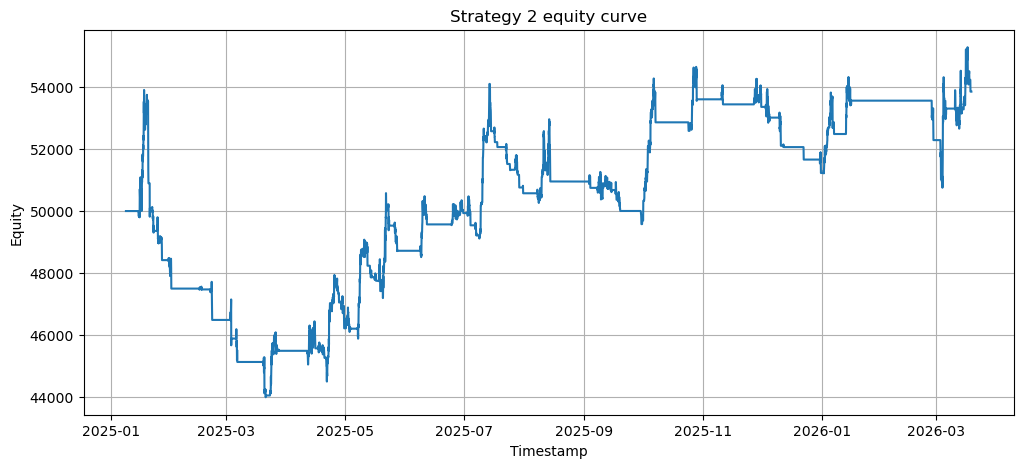

In [438]:
plt.figure(figsize=(12, 5))
plt.plot(backtest_result.equity_curve['timestamp'], backtest_result.equity_curve['equity'])
plt.title('Strategy 2 equity curve')
plt.xlabel('Timestamp')
plt.ylabel('Equity')
plt.grid(True)
plt.show()


## 15) Drawdown

In [ ]:
equity_series = backtest_result.equity_curve.set_index('timestamp')['equity']
drawdown = equity_series / equity_series.cummax() - 1.0

plt.figure(figsize=(12, 4))
plt.plot(drawdown.index, drawdown.values)
plt.title('Strategy 2 drawdown')
plt.xlabel('Timestamp')
plt.ylabel('Drawdown')
plt.grid(True)
plt.show()


## 16) Cash weight and gross exposure through time

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(backtest_result.equity_curve['timestamp'], backtest_result.equity_curve['cash_weight'])
ax[0].set_title('Cash weight')
ax[0].grid(True)

ax[1].plot(backtest_result.equity_curve['timestamp'], backtest_result.equity_curve['gross_exposure'])
ax[1].set_title('Gross exposure')
ax[1].grid(True)

plt.tight_layout()
plt.show()


## 17) Latest target weights vs latest realized weights

In [ ]:
latest_realized_ts = backtest_result.realized_weights.dropna(how='all').index.max()
latest_compare = pd.concat(
    [
        backtest_result.target_weights.loc[latest_realized_ts].rename('target_weight'),
        backtest_result.realized_weights.loc[latest_realized_ts].rename('realized_weight'),
        signal_result.signal.loc[latest_realized_ts].rename('signal'),
    ],
    axis=1,
).sort_values('target_weight', ascending=False)

latest_compare.head(20)


## 18) Daily aggregation of the hourly backtest

In [ ]:
daily_equity = build_daily_equity_curve(backtest_result)
daily_equity.head()


In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(daily_equity['date'], daily_equity['equity'])
plt.title('Daily end-of-day equity')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.grid(True)
plt.show()


## 19) Optional normalization sweep across the four paper parameter pairs

In [96]:
normalization_sweep = run_normalization_sweep(prepared_filtered, config)
normalization_sweep


,short_norm_hours,long_norm_hours,initial_equity,final_equity,total_return,annualized_return,annualized_volatility,sharpe,sortino,max_drawdown,trade_count,turnover_notional,turnover_multiple,average_cash_weight,average_gross_exposure,average_holding_count,pct_time_fully_in_cash
0,24,168,50000.00000,43472.977485,-0.130540,-0.277497,0.118643,-2.338918,-1.951119,-0.179948,5651.0,2.101759e+06,45.287754,0.865472,0.134528,1.447480,0.519363
1,24,720,50000.00000,43454.742552,-0.130905,-0.317458,0.125407,-2.531422,-1.977811,-0.146204,5136.0,1.742943e+06,37.337113,0.854681,0.145319,1.553139,0.535115
2,12,168,49997.91666,39495.765730,-0.210052,-0.420819,0.109216,-3.853101,-2.929270,-0.219615,5205.0,3.119938e+06,69.360989,0.880679,0.119321,1.298784,0.552089
3,12,720,50000.00000,39909.350872,-0.201813,-0.457374,0.111181,-4.113761,-2.975485,-0.203232,4588.0,2.628879e+06,57.997371,0.876512,0.123488,1.346130,0.546749


## Run IS and OOS Experiments Across All Eligible Coins 

In [ ]:
quality_panel

(66, 9)

In [9]:
is_start_date = pd.Timestamp("2025-01-01", tz="UTC")
is_end_date = pd.Timestamp("2025-09-30", tz="UTC") 
oos_start_date = pd.Timestamp("2025-10-01", tz="UTC")
oos_end_date = pd.Timestamp("2026-03-19", tz="UTC")
total_pairs = quality_panel.shape[0]
eligible_pairs = [] # based on earliest valid timestamp of close price data

for i in range(total_pairs):
    pair = quality_panel['pair'].iloc[i]
    asset_start_date = prepared_data.close[pair].first_valid_index()

    if asset_start_date is not pd.NaT and asset_start_date <= is_start_date:
        eligible_pairs.append(pair)

In [10]:
len(eligible_pairs)

44

In [11]:
for pair in eligible_pairs:
    mcap = quality_panel[quality_panel['pair'] == pair]['latest_market_cap_usd'].iloc[0]
    print(f"********************Pair: {pair}, Market Cap: {mcap:,.0f} USD********************")

    # IS test
    print(f"\n=== In-Sample Backtest for {pair} ===") 
    prepared_filtered = filter_prepared_data(
        prepared_data,
        pairs=[pair],
        start=is_start_date,
        end=is_end_date,
    )

    signal_result = compute_hfm_signal(prepared_filtered.close, config.signal)

    target_weights_result = build_long_only_ts_target_weights(
        signal_result.signal,
        long_signal_threshold=config.portfolio.long_signal_threshold,
    )

    backtest_result = run_long_only_hfm_backtest(
        prepared_filtered,
        config,
        signal_result=signal_result,
        target_weights_result=target_weights_result,
    )

    print(
        f"initial_equity: {backtest_result.metrics['initial_equity']:.2f}, "
        f"final_equity: {backtest_result.metrics['final_equity']:.2f}, "
        f"return: {backtest_result.metrics['total_return']:.2%}"
    )

    # OOS test
    print(f"\n=== Out-of-Sample Backtest for {pair} ===") 
    prepared_filtered = filter_prepared_data(
        prepared_data,
        pairs=[pair],
        start=oos_start_date,
        end=oos_end_date,
    )

    signal_result = compute_hfm_signal(prepared_filtered.close, config.signal)

    target_weights_result = build_long_only_ts_target_weights(
        signal_result.signal,
        long_signal_threshold=config.portfolio.long_signal_threshold,
    )

    backtest_result = run_long_only_hfm_backtest(
        prepared_filtered,
        config,
        signal_result=signal_result,
        target_weights_result=target_weights_result,
    )

    print(
        f"initial_equity: {backtest_result.metrics['initial_equity']:.2f}, "
        f"final_equity: {backtest_result.metrics['final_equity']:.2f}, "
        f"return: {backtest_result.metrics['total_return']:.2%}"
    )

********************Pair: AAVE/USD, Market Cap: 1,680,813,758 USD********************

=== In-Sample Backtest for AAVE/USD ===
initial_equity: 50000.00, final_equity: 37511.26, return: -24.98%

=== Out-of-Sample Backtest for AAVE/USD ===
initial_equity: 50000.00, final_equity: 39224.57, return: -21.55%
********************Pair: ADA/USD, Market Cap: 10,246,142,472 USD********************

=== In-Sample Backtest for ADA/USD ===
initial_equity: 50000.00, final_equity: 47547.67, return: -4.90%

=== Out-of-Sample Backtest for ADA/USD ===
initial_equity: 50000.00, final_equity: 37554.57, return: -24.89%
********************Pair: APT/USD, Market Cap: 793,579,485 USD********************

=== In-Sample Backtest for APT/USD ===
initial_equity: 50000.00, final_equity: 37206.17, return: -25.59%

=== Out-of-Sample Backtest for APT/USD ===
initial_equity: 50000.00, final_equity: 39289.97, return: -21.42%
********************Pair: ARB/USD, Market Cap: 602,874,249 USD********************

=== In-Sampl

In [14]:
# Coins with +ve returns in both IS and OOS backtests (no transaction costs and slippages considered)
good_coins = ['NEAR/USD', 'PAXG/USD', 'POL/USD', 'SHIB/USD']

In [15]:
for pair in good_coins:
    mcap = quality_panel[quality_panel['pair'] == pair]['latest_market_cap_usd'].iloc[0]
    print(f"********************Pair: {pair}, Market Cap: {mcap:,.0f} USD********************")

    # IS test
    print(f"\n=== In-Sample Backtest for {pair} ===") 
    prepared_filtered = filter_prepared_data(
        prepared_data,
        pairs=[pair],
        start=is_start_date,
        end=is_end_date,
    )

    signal_result = compute_hfm_signal(prepared_filtered.close, config.signal)

    target_weights_result = build_long_only_ts_target_weights(
        signal_result.signal,
        long_signal_threshold=config.portfolio.long_signal_threshold,
    )

    backtest_result = run_long_only_hfm_backtest(
        prepared_filtered,
        config,
        signal_result=signal_result,
        target_weights_result=target_weights_result,
    )

    print(
        f"initial_equity: {backtest_result.metrics['initial_equity']:.2f}, "
        f"final_equity: {backtest_result.metrics['final_equity']:.2f}, "
        f"return: {backtest_result.metrics['total_return']:.2%}"
    )

    # OOS test
    print(f"\n=== Out-of-Sample Backtest for {pair} ===") 
    prepared_filtered = filter_prepared_data(
        prepared_data,
        pairs=[pair],
        start=oos_start_date,
        end=oos_end_date,
    )

    signal_result = compute_hfm_signal(prepared_filtered.close, config.signal)

    target_weights_result = build_long_only_ts_target_weights(
        signal_result.signal,
        long_signal_threshold=config.portfolio.long_signal_threshold,
    )

    backtest_result = run_long_only_hfm_backtest(
        prepared_filtered,
        config,
        signal_result=signal_result,
        target_weights_result=target_weights_result,
    )

    print(
        f"initial_equity: {backtest_result.metrics['initial_equity']:.2f}, "
        f"final_equity: {backtest_result.metrics['final_equity']:.2f}, "
        f"return: {backtest_result.metrics['total_return']:.2%}"
    )

********************Pair: NEAR/USD, Market Cap: 1,559,677,713 USD********************

=== In-Sample Backtest for NEAR/USD ===
initial_equity: 50000.00, final_equity: 47781.49, return: -4.44%

=== Out-of-Sample Backtest for NEAR/USD ===
initial_equity: 50000.00, final_equity: 57398.42, return: 14.80%
********************Pair: PAXG/USD, Market Cap: 889,460,693 USD********************

=== In-Sample Backtest for PAXG/USD ===
initial_equity: 49927.06, final_equity: 39692.50, return: -20.50%

=== Out-of-Sample Backtest for PAXG/USD ===
initial_equity: 49958.42, final_equity: 49294.36, return: -1.33%
********************Pair: POL/USD, Market Cap: 830,706,519 USD********************

=== In-Sample Backtest for POL/USD ===
initial_equity: 50000.00, final_equity: 49372.20, return: -1.26%

=== Out-of-Sample Backtest for POL/USD ===
initial_equity: 50000.00, final_equity: 55925.30, return: 11.85%
********************Pair: SHIB/USD, Market Cap: 3,547,374,597 USD********************

=== In-Sample

In [ ]:
asset_start_date = prepared_data.close[quality_panel['pair'].iloc[0]].first_valid_index()
asset_start_date


Timestamp('2025-02-09 11:00:00+0000', tz='UTC')